# EDA On Mumbai data

In [5]:
import sqlite3 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# connecting to database
def load_data(city_name):
    
    with sqlite3.connect('../data/weather.db') as conn:
        df = pd.read_sql("""SELECT date, temperature, precipitation,
                     windspeed, humidity FROM weather_daily
                     WHERE city = ?""",conn, params=(city_name,))
        
        df['date'] = pd.to_datetime(df['date'])
        
        df.set_index('date', inplace=True)


        print(f'shape of the data is {df.shape}')
        print(f'First 5 Rows of {city_name}',df.head())

        return df

df = load_data('Mumbai')



shape of the data is (13262, 4)
First 5 Rows of Mumbai             temperature  precipitation  windspeed  humidity
date                                                       
1990-01-01         23.9            0.0       14.3      73.0
1990-01-02         23.7            0.0       19.1      65.0
1990-01-03         23.8            0.0       15.5      73.0
1990-01-04         24.5            0.0       14.4      88.0
1990-01-05         25.8            0.0       13.6      88.0


In [7]:
df.sample(5)

,temperature,precipitation,windspeed,humidity
date,,,,
2020-12-24,23.5,0.0,16.4,87.0
1998-09-19,26.9,4.7,16.8,93.0
2015-10-29,28.6,0.0,13.8,88.0
2010-11-01,26.9,0.0,14.4,83.0
2014-04-01,27.3,0.0,18.9,94.0


In [8]:
df.tail()

,temperature,precipitation,windspeed,humidity
date,,,,
2026-04-19,30.5,0.0,18.4,72.0
2026-04-20,30.1,0.0,14.9,79.0
2026-04-21,30.4,0.0,18.3,87.0
2026-04-22,30.2,0.0,16.7,71.0
2026-04-23,31.3,0.0,16.1,68.0


In [9]:
# checking missing values
print('\n Missing Values : \n', df.isnull().sum())


 Missing Values : 
 temperature      0
precipitation    0
windspeed        0
humidity         0
dtype: int64


In [10]:
df.columns

Index(['temperature', 'precipitation', 'windspeed', 'humidity'], dtype='object')

In [11]:
df.dtypes

temperature      float64
precipitation    float64
windspeed        float64
humidity         float64
dtype: object

<Axes: >

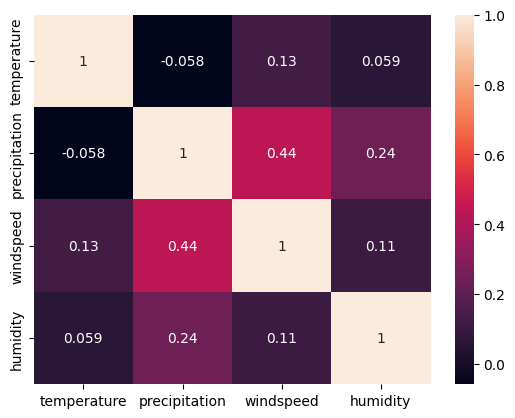

In [12]:
# correlation heatmap
sns.heatmap(df.corr() , annot=True)

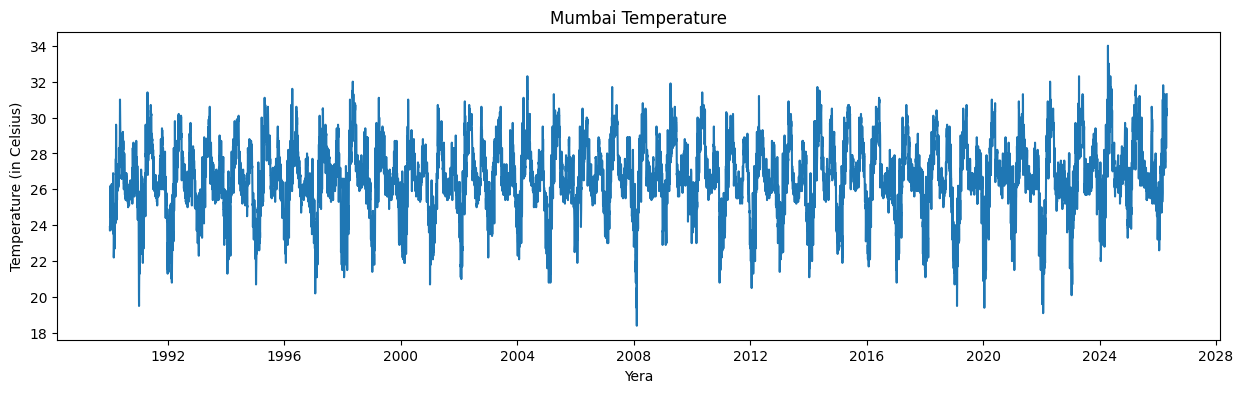

In [13]:
# Plotting
plt.figure(figsize=(15,4))
plt.plot(df['temperature'])
plt.title('Mumbai Temperature')
plt.xlabel('Yera')
plt.ylabel('Temperature (in Celsius)')
plt.show()

C:\Users\himan\AppData\Local\Temp\ipykernel_1984\1543677454.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


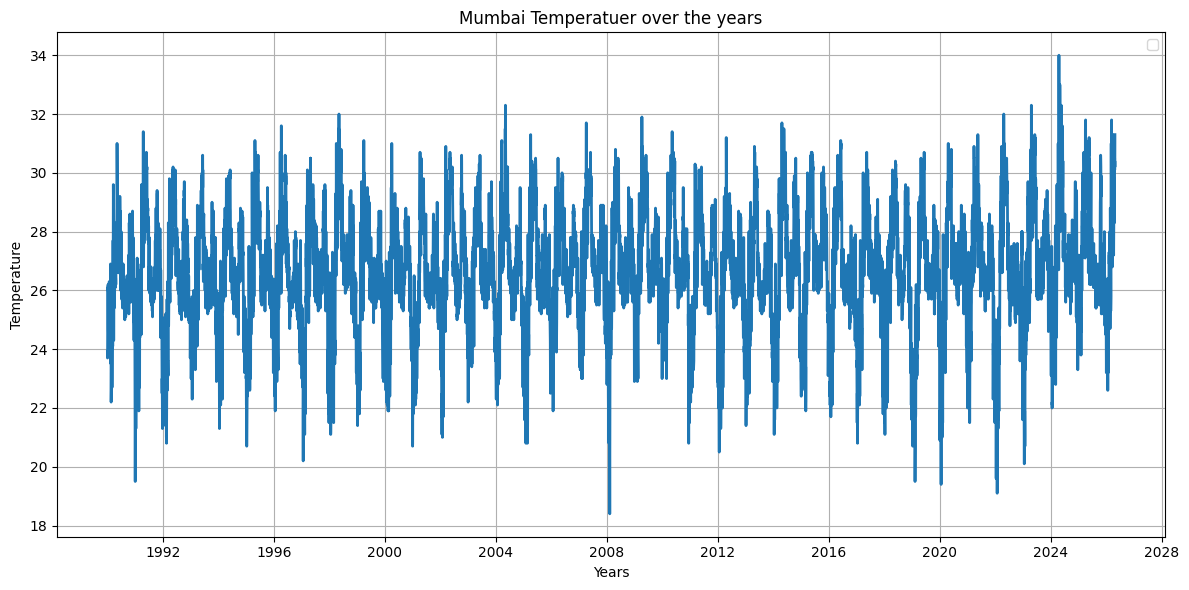

In [14]:
plt.figure(figsize=(12,6))
plt.plot(df['temperature'], linewidth = 2)

plt.title('Mumbai Temperatuer over the years')
plt.xlabel('Years')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
# checking seasonality in better way
summer = df[df.index.month.isin([3,4,5])]
monsoon = df[df.index.month.isin([6,7,8,9,10])]
winter = df[df.index.month.isin([11,12,1,2])]

print("Summer correlation:")
print(summer[['temperature', 'humidity']].corr())

print('\nMonsson Correlation:')
print(monsoon[['temperature', 'humidity']].corr())

print('\nWinter Correlation:')
print(winter[['temperature', 'humidity']].corr())

Summer correlation:
             temperature  humidity
temperature     1.000000 -0.280742
humidity       -0.280742  1.000000

Monsson Correlation:
             temperature  humidity
temperature     1.000000 -0.466962
humidity       -0.466962  1.000000

Winter Correlation:
             temperature  humidity
temperature     1.000000 -0.177091
humidity       -0.177091  1.000000


# Observations :
- No same mean every year                -> suggest NON-stationary
- Same ups and downs every year          -> suggest stationary
- Permanent up/down movement             -> suggest NON-stationary 

# Decomposition and Stationary Testing

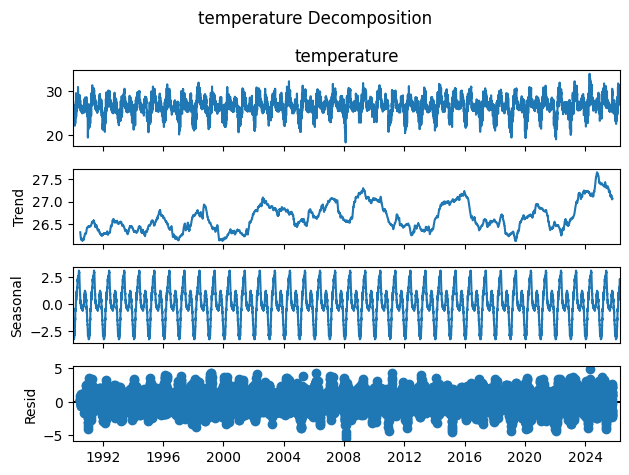

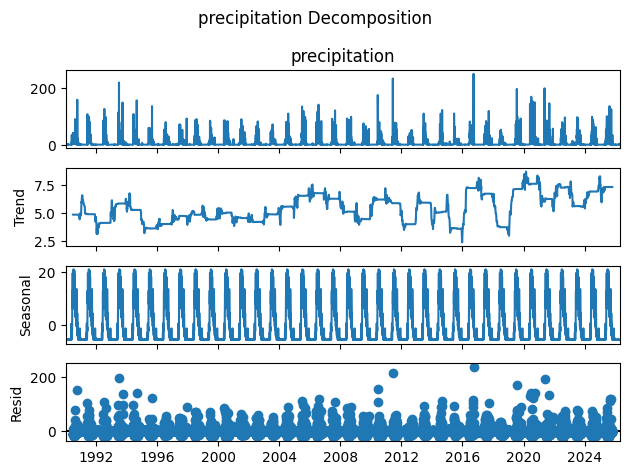

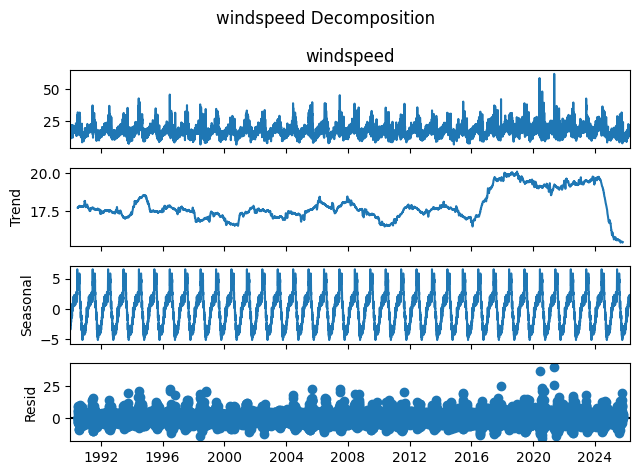

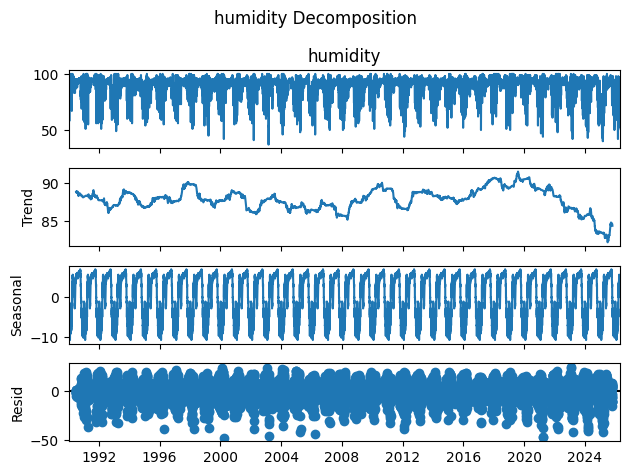

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

variables = ['temperature', 'precipitation', 'windspeed', 'humidity']

for var in variables:
    result = seasonal_decompose(df[var], 
                                model='additive', 
                                period=365)
    result.plot()
    plt.suptitle(f'{var} Decomposition')
    plt.tight_layout()
    plt.show()

# Augmented Dickey-Fuller (ADF) stationarity test

In [19]:
from statsmodels.tsa.stattools import adfuller

for var in ['temperature','precipitation','windspeed','humidity']:
    result = adfuller(df[var])
    p = result[1]
    status = 'Stationary ✅' if p < 0.05 else 'Non-stationary ❌'
    print(f'{var:<15} p={p:.4f}  {status}')

temperature     p=0.0000  Stationary ✅
precipitation   p=0.0000  Stationary ✅
windspeed       p=0.0000  Stationary ✅
humidity        p=0.0000  Stationary ✅


In [23]:
# KPSS test — better at detecting seasonality
from statsmodels.tsa.stattools import kpss

for var in ['temperature','precipitation','windspeed','humidity']:
    result = kpss(df[var])
    p = result[1]
    status = 'Stationary ✅' if p > 0.05 else 'Non-stationary ❌'
    print(f'{var:<15} p={p:.4f}  {status}')

temperature     p=0.1000  Stationary ✅
precipitation   p=0.1000  Stationary ✅
windspeed       p=0.0755  Stationary ✅
humidity        p=0.1000  Stationary ✅


C:\Users\himan\AppData\Local\Temp\ipykernel_1984\396977005.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(df[var])
C:\Users\himan\AppData\Local\Temp\ipykernel_1984\396977005.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(df[var])
C:\Users\himan\AppData\Local\Temp\ipykernel_1984\396977005.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(df[var])
